In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("../data/pseudo_labeled_tickets.csv")

df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,...,Keyword_Score,Resolution_Score,Semantic_Score,Final_Severity_Score,Keyword_Score_Normalized,Resolution_Score_Normalized,Inferred_Severity,Mismatch_Label,Mismatch_Type,Severity_Delta
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,...,0,2,0.593736,0.430201,0.000000,0.666667,Medium,0,Consistent,-1
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,...,0,2,0.173507,0.220087,0.000000,0.666667,Low,1,False Alarm,-2
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,...,0,3,0.588986,0.494493,0.000000,1.000000,High,0,Consistent,0
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,...,4,2,0.095357,0.352440,0.571429,0.666667,Low,0,Consistent,0
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,...,0,2,0.649460,0.458063,0.000000,0.666667,Medium,0,Consistent,0


In [4]:
df["Combined_Text"] = (
    df["Ticket_Subject"]
    + " "
    + df["Ticket_Description"]
)

In [5]:
X = df[
    [
        "Combined_Text",
        "Issue_Category",
        "Ticket_Channel",
        "Resolution_Time_Hours"
    ]
]

y = df["Mismatch_Label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "text",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1,2)
            ),
            "Combined_Text"
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            [
                "Issue_Category",
                "Ticket_Channel"
            ]
        ),

        (
            "num",
            "passthrough",
            [
                "Resolution_Time_Hours"
            ]
        )

    ]

)

In [8]:
model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            XGBClassifier(

                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,

                random_state=42,

                scale_pos_weight=
                y_train.value_counts()[0] /
                y_train.value_counts()[1]

            )

        )

    ]

)

In [9]:
model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
pred = model.predict(
    X_test
)

In [11]:
acc = accuracy_score(
    y_test,
    pred
)

print(
    f"Accuracy : {acc:.4f}"
)

Accuracy : 0.7610


In [12]:
print(

    classification_report(
        y_test,
        pred
    )

)

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      2912
           1       0.54      0.81      0.65      1088

    accuracy                           0.76      4000
   macro avg       0.73      0.78      0.73      4000
weighted avg       0.81      0.76      0.77      4000



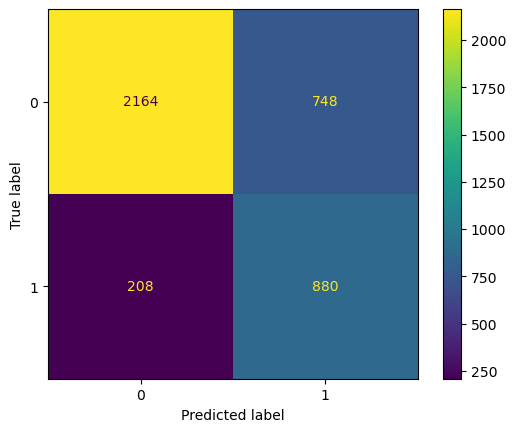

In [13]:
cm = confusion_matrix(
    y_test,
    pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [15]:
import joblib

joblib.dump(
    model,
    "../models/xgb_pipeline.pkl"
)

['../models/xgb_pipeline.pkl']

In [16]:
print(y_train.value_counts())

print(
    y_train.value_counts(
        normalize=True
    )
)

Mismatch_Label
0    11647
1     4353
Name: count, dtype: int64
Mismatch_Label
0    0.727938
1    0.272062
Name: proportion, dtype: float64


In [17]:
### Training Data Distribution

#The pseudo-labeled dataset exhibits moderate class imbalance:

#- Consistent Tickets: 11,647 (72.8%)
#- Mismatched Tickets: 4,353 (27.2%)

#To mitigate the impact of imbalance, the XGBoost classifier uses the `scale_pos_weight` parameter, which automatically increases the importance of the minority (Mismatch) class during training.

In [18]:
print(
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

2.675626005053986


In [19]:
XGBClassifier(

    objective="binary:logistic",

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    eval_metric="logloss",

    random_state=42,

    scale_pos_weight=
    y_train.value_counts()[0] /
    y_train.value_counts()[1]

)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [20]:
model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
pred = model.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.761
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      2912
           1       0.54      0.81      0.65      1088

    accuracy                           0.76      4000
   macro avg       0.73      0.78      0.73      4000
weighted avg       0.81      0.76      0.77      4000



In [22]:
X = df[
[
    "Combined_Text",
    "Issue_Category",
    "Ticket_Channel",
    "Resolution_Time_Hours",
    "Keyword_Score",
    "Semantic_Score",
    "Final_Severity_Score"
]
]

In [23]:
preprocessor = ColumnTransformer(

transformers=[

(
"text",
TfidfVectorizer(
max_features=5000,
ngram_range=(1,2)
),
"Combined_Text"
),

(
"cat",
OneHotEncoder(
handle_unknown="ignore"
),
[
"Issue_Category",
"Ticket_Channel"
]
),

(
"num",
"passthrough",
[
"Resolution_Time_Hours",
"Keyword_Score",
"Semantic_Score",
"Final_Severity_Score"
]
)

]

)

In [24]:
min_child_weight=3,
gamma=0.2,

In [25]:
XGBClassifier(

objective="binary:logistic",

n_estimators=300,
max_depth=6,
learning_rate=0.05,

subsample=0.8,
colsample_bytree=0.8,

min_child_weight=3,
gamma=0.2,

eval_metric="logloss",

random_state=42,

scale_pos_weight=
y_train.value_counts()[0] /
y_train.value_counts()[1]

)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [26]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.761
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      2912
           1       0.54      0.81      0.65      1088

    accuracy                           0.76      4000
   macro avg       0.73      0.78      0.73      4000
weighted avg       0.81      0.76      0.77      4000



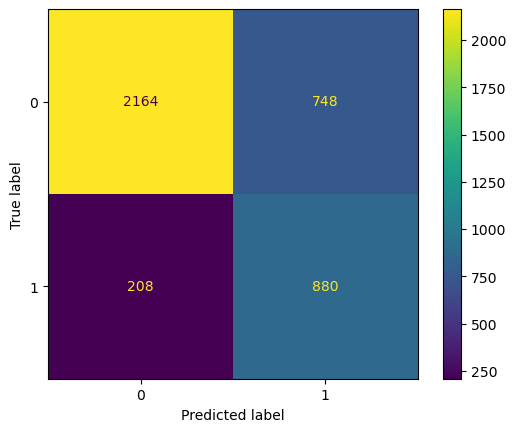

In [27]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [28]:
import joblib

joblib.dump(
    model,
    "../models/xgb_pipeline.pkl"
)

['../models/xgb_pipeline.pkl']

In [29]:
df.to_csv(
    "../data/pseudo_labeled_tickets.csv",
    index=False
)